# Local Regression

In [1]:
# Standard imports and abbreviations
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Tools and metrics for regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Needed to suppress warnings with polynomial fit
import warnings

# Needed to provide type hints for functions passed as arguments
from typing import Callable

In [2]:
# Generate synthetic data
np.random.seed(13)
X = np.linspace(0, 10, 100)
y = np.sin(X) * np.cos(X) + X**2 / 10 + np.random.normal(0, 0.5, 100)  # Complex and noisy data

# Split the data into training, validation, and testing sets

# For fitting the function once hyperparameters are selected
X_train_val = np.concatenate((X_train, X_val))
y_train_val = np.concatenate((y_train, y_val))

In [3]:
def kernel(x0:float, X:np.ndarray, 
           lam:float, D:Callable) -> np.ndarray:
    """
    Returns 1D numpy array of kernel values of X centered at x0
    """

    kernel_values = [D(np.abs(xi - x0) / lam) for xi in X]

    return kernel_values

In [4]:
def quadratic(t:float) -> float:
    """
    Returns value of quadratic density function at t
    """
    
    if np.abs(t) <= 1:
        return 0.75*(1-t**2)
    else:
        return 0

def tricube(t:float) -> float:
    """
    Returns value of tri-cube density function at t
    """
    
    if np.abs(t) <= 1:
        return (1-np.abs(t)**3)**3
    else:
        return 0
 
def gaussian(t:float, mu:float=0, 
             sigma:float=1) -> float:
    """
    Returns value of Gaussian density function at t, with mean 0 and standard deviation 1
    """
    
    return (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-((t - mu) ** 2 / (2 * sigma ** 2)))

In [5]:
def local_regression(x0:float, X:np.ndarray, y:np.ndarray, 
                     lam:float, K:Callable, D:Callable) -> float:
    """
    Computes estimate of y0 using local linear regression at point x0 with training sets X and y
    """
    
    # Calculate the weights using the kernel
    weights = K(x0, X, lam, D)
    
    # Fit a weighted linear regression model
    model = sm.WLS(y, sm.add_constant(X), weights=weights)
    results = model.fit()
    
    # Predict the value at x0
    y_pred = results.predict([1, x0])  # Add a constant term for the intercept
    
    return y_pred[0] # y_pred is a numpy array with one element

In [7]:
lam_values = np.arange(0.1, 2.6, 0.1) # We choose to check lambda values from 0.1 to 2.5

In [8]:
validation_mse = [] # selection will be made based on validation MSE
validation_r2 = [] # validation R^2 is also looked at, but not directly used. 

for lam in lam_values:
    
    # Predict on the validation set
    y_pred_val = [local_regression(x0, X_train, y_train, lam, kernel, D) for x0 in X_val]
    
    # Calculate Mean Squared Error (MSE) on the validation set
    mse = mean_squared_error(y_val, y_pred_val)
    
    # Calculate R-squared (R2) on the validation set
    r2 = r2_score(y_val, y_pred_val)
    
    # Append corresponding metrics to lists
    validation_mse.append(mse)
    validation_r2.append(r2)

# Find the best lambda based on validation set mean squared error
best_lambda = lam_values[np.argmin(validation_mse)]
print(f"Best lambda based on validation set MSE: {best_lambda}")

Best lambda based on validation set MSE: 0.5


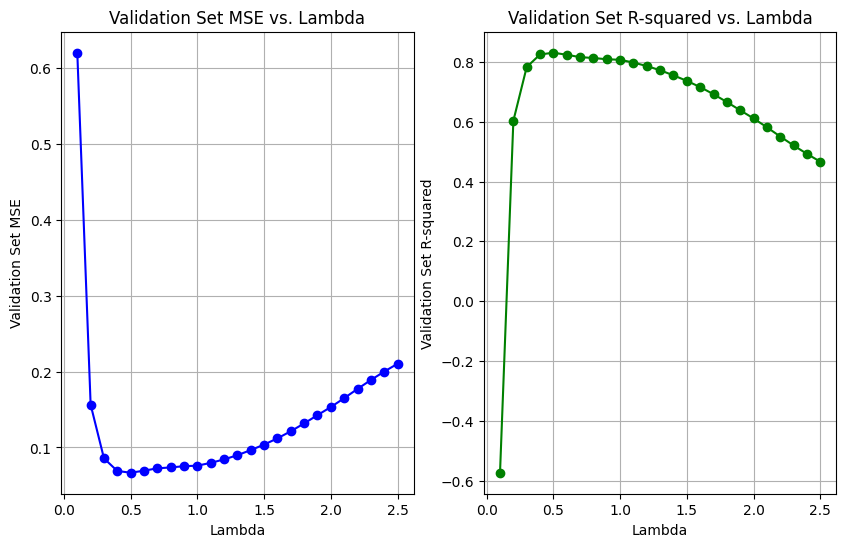

In [9]:
# Plot lambda values vs. validation set metrics
plt.figure(figsize=(10, 6))
plt.subplot(121)
plt.plot(lam_values, validation_mse, marker='o', linestyle='-', color='blue')
plt.title('Validation Set MSE vs. Lambda')
plt.xlabel('Lambda')
plt.ylabel('Validation Set MSE')
plt.grid(True)

plt.subplot(122)
plt.plot(lam_values, validation_r2, marker='o', linestyle='-', color='green')
plt.title('Validation Set R-squared vs. Lambda')
plt.xlabel('Lambda')
plt.ylabel('Validation Set R-squared')
plt.grid(True)

Mean Squared Error on testing set with best lambda (0.5): 0.0453
R-squared on testing set with best lambda (0.5): 0.9010


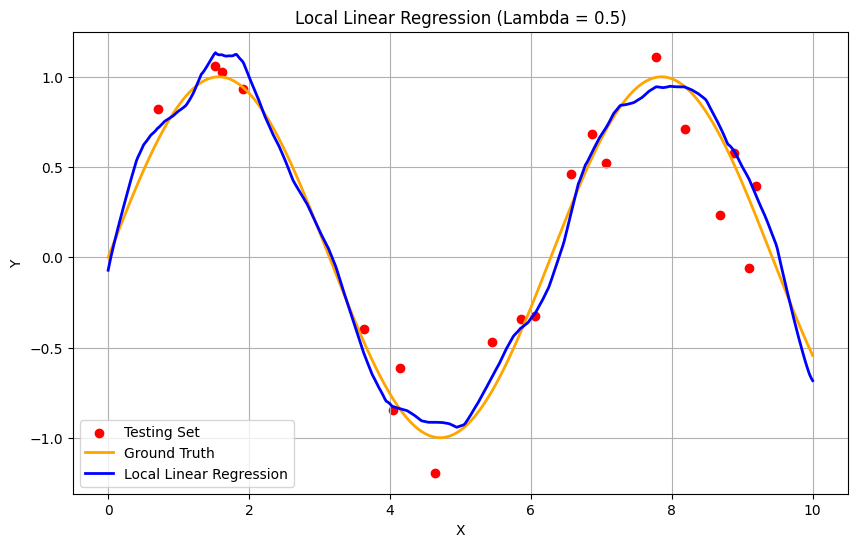

In [10]:
# Iterate through X_range and calculate y_pred using local regression
y_pred_plot = [local_regression(x0, X_train_val, y_train_val, 
                                best_lambda, kernel, D) for x0 in X_range]

# Iterate through X_test and calculate y_pred using local regression
y_pred_test = [local_regression(x0, X_train_val, y_train_val, 
                                best_lambda, kernel, D) for x0 in X_test]

# Calculate MSE and R2 on the testing set
test_mse = mean_squared_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)
print(f"Mean Squared Error on testing set with best lambda ({best_lambda}): {test_mse:.4f}")
print(f"R-squared on testing set with best lambda ({best_lambda}): {test_r2:.4f}")

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='red', label='Testing Set')
plt.plot(X_range, y_truth, label=f'Ground Truth', color='orange', linewidth=2)
plt.plot(X_range, y_pred_plot, color='blue', lw=2, label='Local Linear Regression')
plt.title(f'Local Linear Regression (Lambda = {best_lambda})')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()


# Write up

Write a blurb explaining your work above.